# Diabetes Prediction Model

An end-to-end machine learning project for predicting diabetes using the **PIMA Indians Diabetes Dataset**. This notebook covers data exploration, preprocessing, model training with Logistic Regression, evaluation, and model serialization for deployment via a Flask API.

---
## 1. Import Dependencies

In [1]:
import numpy as np 
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pickle 

---
## 2. Load and Explore the Dataset

The dataset contains medical predictor variables and the target outcome (1 = diabetic, 0 = non-diabetic). We check for duplicates, missing values, and summary statistics.

In [3]:
 # load dataset
data = pd.read_csv('diabetes.csv')

In [4]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
data.duplicated().sum()

np.int64(0)

In [7]:
data.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [9]:
data.skew()

Pregnancies                 0.901674
Glucose                     0.173754
BloodPressure              -1.843608
SkinThickness               0.109372
Insulin                     2.272251
BMI                        -0.428982
DiabetesPedigreeFunction    1.919911
Age                         1.129597
Outcome                     0.635017
dtype: float64

---
## 3. Exploratory Data Analysis

Visualizing the distribution of each feature using histograms to understand their spread and identify anomalies.

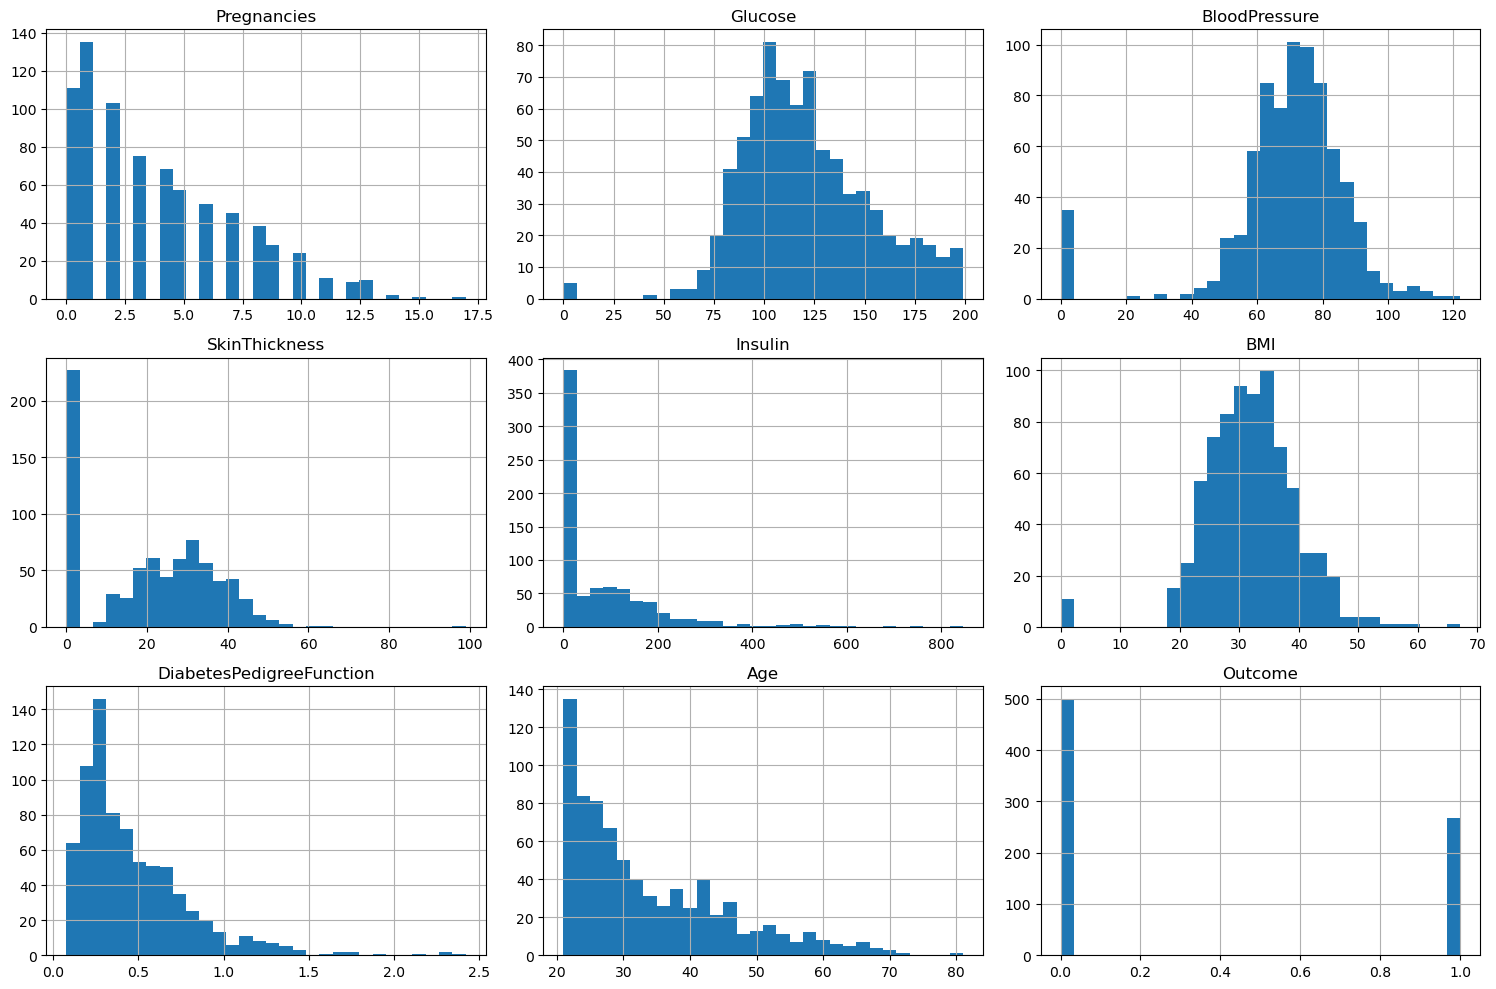

In [13]:
import matplotlib.pyplot as plt


data.hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()


---
## 4. Data Preprocessing - Handling Zero Values

Some features like Glucose, BloodPressure, SkinThickness, Insulin, and BMI cannot logically be zero. We replace zero values with NaN and impute them using the median of each column.

In [14]:
(data == 0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [18]:
missing_zero_columns = ['SkinThickness','Insulin','BloodPressure','Glucose','BMI']
data[missing_zero_columns] = data[missing_zero_columns].replace(0,np.nan)
for colmn in missing_zero_columns :
    data[colmn] = data[colmn].fillna(data[colmn].median())
(data==0).sum()

Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

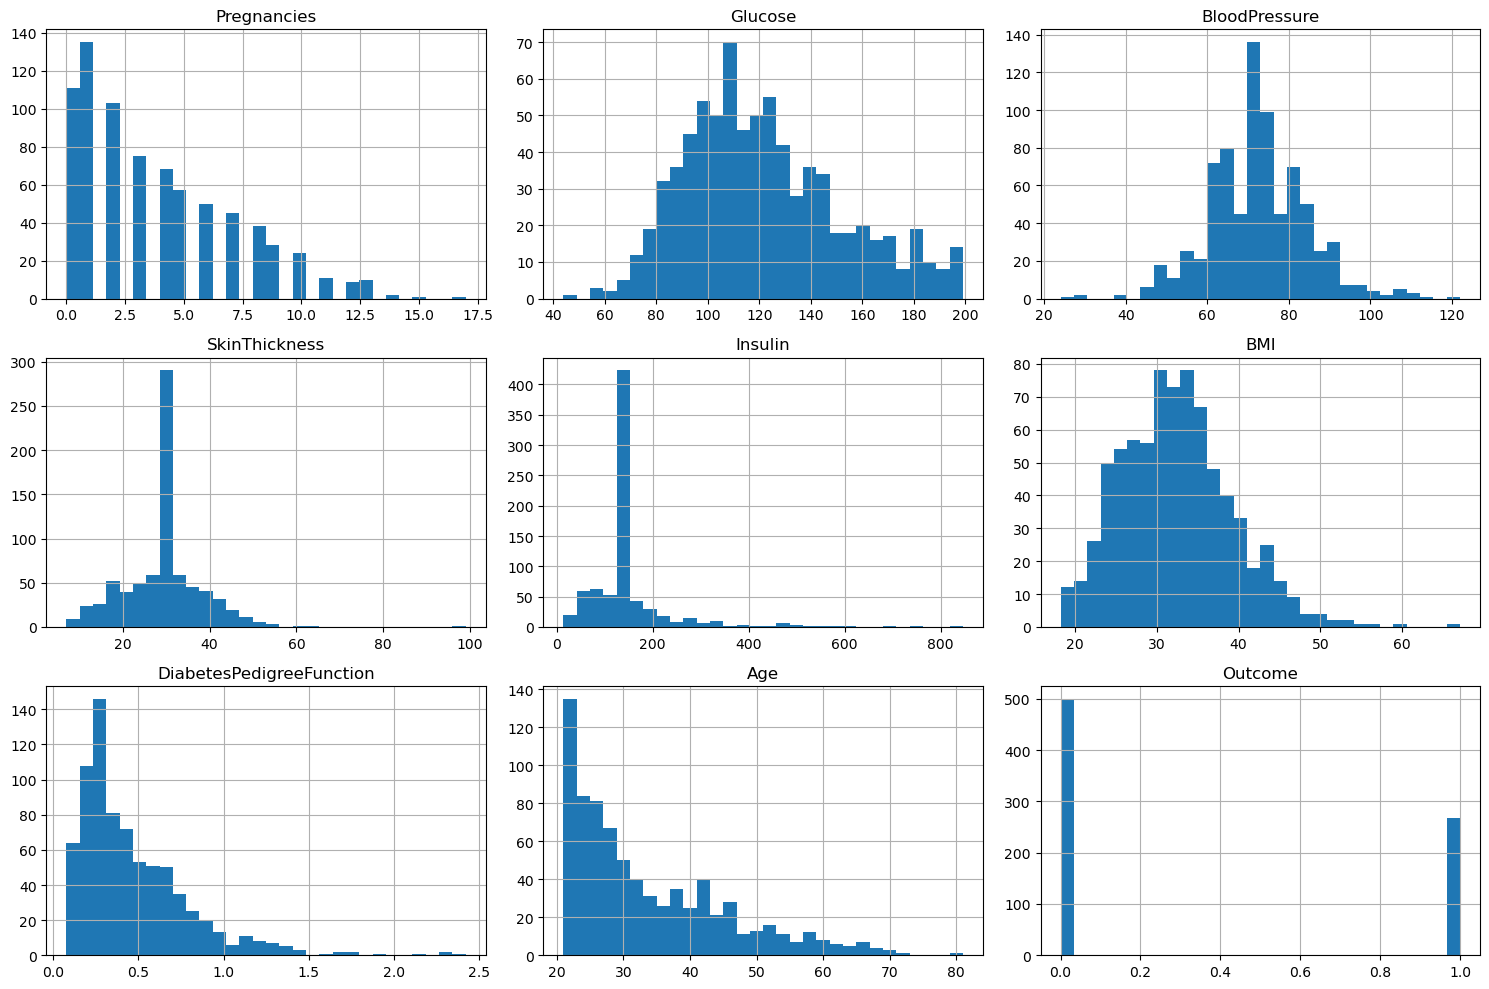

In [19]:
data.hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

---
## 5. Split Features and Target

Separate the dataset into features (X) and target labels (y).

In [20]:
X = data.drop(columns=["Outcome"])
y = data["Outcome"]

In [21]:
X

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63
764,2,122.0,70.0,27.0,125.0,36.8,0.340,27
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30
766,1,126.0,60.0,29.0,125.0,30.1,0.349,47


In [22]:
y

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

---
## 6. Train-Test Split

Split the data into training (80%) and testing (20%) sets with stratification to maintain class balance.

In [23]:
# split the data to training data and test data
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2,stratify=y,random_state=42)

In [25]:
print(y.shape,y_train.shape,y_test.shape)

(768,) (614,) (154,)


---
## 7. Feature Scaling

Standardize features by removing the mean and scaling to unit variance using `StandardScaler`.

In [26]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

---
## 8. Train Logistic Regression Model

Train a Logistic Regression classifier on the scaled training data.

In [27]:
# train the Logistic Regression model
model = LogisticRegression()

In [28]:
model.fit(X_train_scaled,y_train)

LogisticRegression()

---
## 9. Evaluate the Model

Evaluate model performance on both training and test sets using accuracy score.

In [30]:
y_pred_train = model.predict(X_train_scaled)

accuracy = accuracy_score(y_train,y_pred_train)
print("Training accureacy:",round(accuracy,2))

Training accureacy: 0.8


In [31]:
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test,y_pred)
print("accuracy",round(accuracy,2))

accuracy 0.71


---
## 10. Save the Model and Scaler

Serialize the trained model and scaler using pickle for later use in the Flask API.

In [33]:
# save the trained model and scaler as pickle file 

with open("diabetes_model.pkl","wb") as model_file:
    pickle.dump(model , model_file)
with open("scaler_model.pkl","wb") as scaler_file:
    pickle.dump(scaler , scaler_file)

---
## 11. Load the Saved Model and Make Predictions

Demonstrate loading the saved model and scaler, then making a prediction on a new data point.

**Code for Prediction**

In [34]:
import pickle 
import numpy as np 

with open("diabetes_model.pkl","rb") as model_file:
    loaded_model = pickle.load(model_file)
with open("scaler_model.pkl","rb") as scaler_file:
    loaded_scaler = pickle.load(scaler_file)

In [36]:
new_data_point = [1, 189, 60, 23, 846, 30.1, 0.398, 59]

In [37]:
scaled_data = loaded_scaler.transform([new_data_point])

/home/yaseen/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [39]:
scaled_data

array([[-0.85135507,  2.24584551, -0.98980408, -0.68009112,  8.99986517,
        -0.34416867, -0.24066919,  2.1679625 ]])

In [40]:
prediction = loaded_model.predict(scaled_data)

In [41]:
prediction

array([1])

In [43]:
print(prediction[0])

1


In [44]:
if prediction[0] == 1 :
    print("Diabetic")
else :
    print("Non Diabetic")

Diabeteic
